<a href="https://colab.research.google.com/github/chiraswykj/ML2_Lab_ChiraswyKJ_4NI23CI028/blob/main/ML_Exp4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TRAINING DATASET


,Sky,AirTemp,Humidity,Wind,Water,Forecast,EnjoySport
0,Sunny,Warm,Normal,Strong,Warm,Same,Yes
1,Sunny,Warm,High,Strong,Warm,Same,Yes
2,Rainy,Cold,High,Strong,Warm,Change,No
3,Sunny,Warm,High,Strong,Cool,Change,Yes



Attributes:
['Sky', 'AirTemp', 'Humidity', 'Wind', 'Water', 'Forecast']

Initial Specific Boundary (S):
['0', '0', '0', '0', '0', '0']

Initial General Boundary (G):
[['?', '?', '?', '?', '?', '?']]

Attribute Domains:
Sky : ['Sunny', 'Rainy']
AirTemp : ['Warm', 'Cold']
Humidity : ['Normal', 'High']
Wind : ['Strong']
Water : ['Warm', 'Cool']
Forecast : ['Same', 'Change']


CANDIDATE ELIMINATION PROCESS

------------------------------------------------------------
Example 1
Instance : ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same']
Target   : Yes

Positive Example

Specific Boundary (S):
['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same']

General Boundary (G):
['?', '?', '?', '?', '?', '?']

------------------------------------------------------------
Example 2
Instance : ['Sunny', 'Warm', 'High', 'Strong', 'Warm', 'Same']
Target   : Yes

Positive Example

Specific Boundary (S):
['Sunny', 'Warm', '?', 'Strong', 'Warm', 'Same']

General Boundary (G):
['?', '?', '?', '?', '?', '

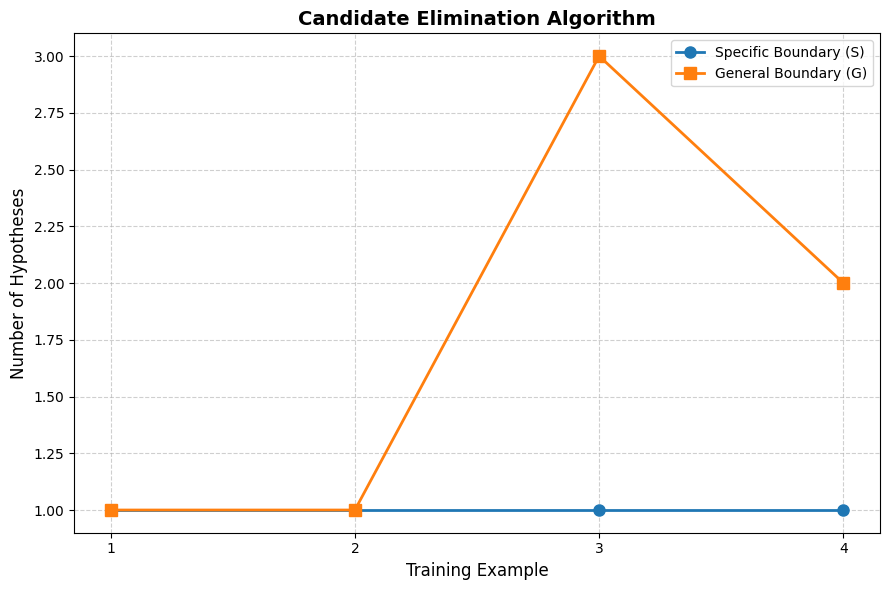

In [ ]:
# ============================================================
# CANDIDATE ELIMINATION ALGORITHM
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. CREATE DATASET
# ============================================================

data = {
    'Sky': ['Sunny', 'Sunny', 'Rainy', 'Sunny'],
    'AirTemp': ['Warm', 'Warm', 'Cold', 'Warm'],
    'Humidity': ['Normal', 'High', 'High', 'High'],
    'Wind': ['Strong', 'Strong', 'Strong', 'Strong'],
    'Water': ['Warm', 'Warm', 'Warm', 'Cool'],
    'Forecast': ['Same', 'Same', 'Change', 'Change'],
    'EnjoySport': ['Yes', 'Yes', 'No', 'Yes']
}

df = pd.DataFrame(data)

print("TRAINING DATASET")
print("=" * 60)
display(df)


# ============================================================
# 2. INITIALIZE ATTRIBUTES
# ============================================================

attributes = list(df.columns[:-1])
num_attributes = len(attributes)

print("\nAttributes:")
print(attributes)


# ============================================================
# 3. INITIALIZE S AND G
# ============================================================

# Most specific hypothesis
S = ['0'] * num_attributes

# Most general hypothesis
G = [['?'] * num_attributes]

print("\nInitial Specific Boundary (S):")
print(S)

print("\nInitial General Boundary (G):")
print(G)


# ============================================================
# 4. HELPER FUNCTIONS
# ============================================================

def covers(hypothesis, instance):
    """
    Checks whether a hypothesis covers an instance.
    """
    for h, x in zip(hypothesis, instance):
        if h != '?' and h != x:
            return False
    return True


def more_general(h1, h2):
    """
    Checks whether h1 is more general than or equal to h2.
    """
    for h1_value, h2_value in zip(h1, h2):

        if h1_value == '?':
            continue

        if h1_value == h2_value:
            continue

        if h2_value == '0':
            continue

        return False

    return True


def minimal_generalization(s, instance):
    """
    Performs minimal generalization of S
    to cover a positive example.
    """

    new_s = s.copy()

    for i in range(num_attributes):

        if new_s[i] == '0':
            new_s[i] = instance[i]

        elif new_s[i] != instance[i]:
            new_s[i] = '?'

    return new_s


def minimal_specializations(g, instance, domains):
    """
    Performs minimal specialization of G
    so that it does not cover a negative example.
    """

    specializations = []

    for i in range(num_attributes):

        if g[i] == '?':

            for value in domains[i]:

                if value != instance[i]:

                    new_g = g.copy()
                    new_g[i] = value

                    specializations.append(new_g)

    return specializations


# ============================================================
# 5. FIND ALL POSSIBLE VALUES FOR EACH ATTRIBUTE
# ============================================================

domains = []

for attribute in attributes:
    domains.append(df[attribute].unique().tolist())

print("\nAttribute Domains:")
for attribute, values in zip(attributes, domains):
    print(attribute, ":", values)


# ============================================================
# 6. CANDIDATE ELIMINATION ALGORITHM
# ============================================================

# Store values for plotting
example_numbers = []
s_sizes = []
g_sizes = []

print("\n\nCANDIDATE ELIMINATION PROCESS")
print("=" * 70)


for index, row in df.iterrows():

    # Get input attributes
    instance = row[attributes].tolist()

    # Get target value
    target = row['EnjoySport']

    print("\n------------------------------------------------------------")
    print("Example", index + 1)
    print("Instance :", instance)
    print("Target   :", target)

    # ========================================================
    # POSITIVE EXAMPLE
    # ========================================================

    if target == 'Yes':

        print("\nPositive Example")

        # Remove G hypotheses that don't cover instance
        G = [
            g for g in G
            if covers(g, instance)
        ]

        # Generalize S if required
        if not covers(S, instance):

            S = minimal_generalization(
                S,
                instance
            )

        # Remove hypotheses in G that are
        # less general than S
        G = [
            g for g in G
            if more_general(g, S)
        ]

    # ========================================================
    # NEGATIVE EXAMPLE
    # ========================================================

    else:

        print("\nNegative Example")

        new_G = []

        for g in G:

            # If G covers negative example,
            # specialize it
            if covers(g, instance):

                specializations = minimal_specializations(
                    g,
                    instance,
                    domains
                )

                # Keep only hypotheses that are
                # more general than S
                for specialization in specializations:

                    if more_general(
                        specialization,
                        S
                    ):

                        new_G.append(
                            specialization
                        )

            else:

                new_G.append(g)

        G = new_G

    # ========================================================
    # DISPLAY CURRENT BOUNDARIES
    # ========================================================

    print("\nSpecific Boundary (S):")
    print(S)

    print("\nGeneral Boundary (G):")

    if len(G) == 0:
        print("No hypotheses")

    else:
        for g in G:
            print(g)

    # ========================================================
    # SAVE DATA FOR GRAPH
    # ========================================================

    example_numbers.append(index + 1)

    # S normally contains one hypothesis
    s_sizes.append(1 if S else 0)

    # Number of hypotheses in G
    g_sizes.append(len(G))


# ============================================================
# 7. FINAL VERSION SPACE
# ============================================================

print("\n\n")
print("=" * 70)
print("FINAL VERSION SPACE")
print("=" * 70)

print("\nFinal Specific Boundary (S):")
print(S)

print("\nFinal General Boundary (G):")

if len(G) == 0:
    print("No hypotheses")

else:
    for g in G:
        print(g)


# ============================================================
# 8. PLOT GRAPH
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    example_numbers,
    s_sizes,
    marker='o',
    linewidth=2,
    markersize=8,
    label='Specific Boundary (S)'
)

plt.plot(
    example_numbers,
    g_sizes,
    marker='s',
    linewidth=2,
    markersize=8,
    label='General Boundary (G)'
)

plt.xlabel(
    'Training Example',
    fontsize=12
)

plt.ylabel(
    'Number of Hypotheses',
    fontsize=12
)

plt.title(
    'Candidate Elimination Algorithm',
    fontsize=14,
    fontweight='bold'
)

plt.xticks(example_numbers)

plt.grid(
    True,
    linestyle='--',
    alpha=0.6
)

plt.legend()

plt.tight_layout()

plt.show()
